## 亲本不对等效应
作者：曹明浩    时间：2026.2.24

### 1、 导入Python模块

In [4]:
import polars as pl
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind
import matplotlib.patches as mpatches

### 2、 导入数据

In [34]:
all_desc_parquet = rf'F:\04.Data_v2\caominghao_v4\f13.descriptive_stat'
yj_desc_data_wide = pl.scan_parquet(rf'{all_desc_parquet}/desc_data_negaeffectFemale_chrom_*_or_wide.parquet').collect()
print({type(yj_desc_data_wide)})
yj_desc_data_wide.shape
# 10. polars格式转为pandas格式
yj_desc_data_wide = yj_desc_data_wide.to_pandas()
yj_desc_data_wide.head()

{<class 'polars.dataframe.frame.DataFrame'>}


,chra,windowa,trait_id,median_M,median_P,iqr_M,iqr_P,cv_M,cv_P,qcd_M,qcd_P,lnMR,lnIQRR,lnCVR,lnQCDR,x_group_P,x_group_M
0,1,0,101,0.24445,0.22917,0.30786,0.25899,0.727556,0.698897,0.846754,0.811475,-0.064547,-0.172856,-0.040188,-0.042557,0.6-0.8,0.6-0.8
1,1,1,101,0.24445,0.22917,0.30786,0.25899,0.727556,0.698897,0.846754,0.811475,-0.064547,-0.172856,-0.040188,-0.042557,0.6-0.8,0.6-0.8
2,1,2,101,0.24360,0.23125,0.31572,0.26169,0.735916,0.696904,0.852203,0.808313,-0.052028,-0.187695,-0.054468,-0.052876,0.6-0.8,0.6-0.8
3,1,3,101,0.23116,0.23445,0.30394,0.26333,0.754082,0.694797,0.850117,0.809644,0.014132,-0.143422,-0.081882,-0.048780,0.6-0.8,0.6-0.8
4,1,4,101,0.22833,0.23500,0.30022,0.27455,0.743749,0.693782,0.846874,0.821732,0.028794,-0.089382,-0.069546,-0.030138,0.6-0.8,0.6-0.8


### 3、 可视化（绘制全部的点）
原文件过大

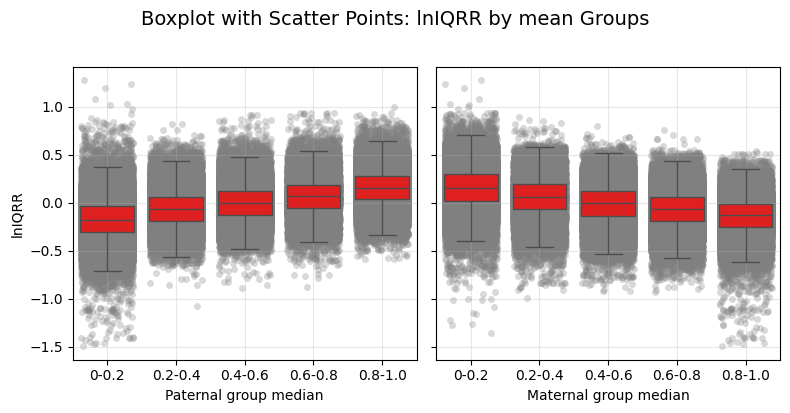

In [3]:
y_label = 'lnIQRR'
x_label = 'median'
x_label_P = f'Paternal group {x_label}'
x_label_M = f'Maternal group {x_label}'
order = ['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharey = True)

# 使用zorder明确控制图层顺序（数值越大越在上面）
sns.boxplot(data=yj_desc_data_wide, 
            x='x_group_P', 
            y=y_label, 
            #hue='x_group', palette='pastel', 
            legend=False, # close legend
            order=order,
            showfliers=False, # close outliers
            zorder=10, # top layer
            width = 0.78, 
            color = 'red', #'#303BDB' # color
            ax = ax1
           )  # 箱线图在底层
sns.stripplot(data=yj_desc_data_wide, 
              x='x_group_P', 
              y=y_label, 
              color='grey', 
              alpha=0.3, 
              jitter=0.38, 
              zorder=0,
              ax = ax1)
ax1.set_xlabel(f'{x_label_P}')
ax1.set_ylabel(f'{y_label}')
ax1.tick_params(axis='x', rotation=0)
ax1.grid(True, alpha=0.3)



# 使用zorder明确控制图层顺序（数值越大越在上面）
sns.boxplot(data=yj_desc_data_wide, 
            x='x_group_M', 
            y=y_label, 
            #hue='x_group', palette='pastel', 
            order=order,
            legend=False, # close legend
            showfliers=False, # close outliers
            zorder=10, # top layer
            width = 0.78, 
            color = 'red', #'#303BDB' # color
            ax = ax2
           )  # 箱线图在底层
sns.stripplot(data=yj_desc_data_wide, 
              x='x_group_M', 
              y=y_label, 
              color='grey', 
              alpha=0.3, 
              jitter=0.38, 
              zorder=0,
              ax = ax2)
ax2.set_xlabel(f'{x_label_M}')
ax2.set_ylabel(f'{y_label}')
ax2.tick_params(axis='x', rotation=0)
ax2.grid(True, alpha=0.3)


# 添加居中的总标题
fig.suptitle(f'Boxplot with Scatter Points: {y_label} by mean Groups', fontsize=14, y=1.02)

plt.tight_layout()
plt.savefig(plot_path, format='pdf', dpi=300, bbox_inches='tight')

plt.show()

### 4、 IQR与Median
* IQR
* Median

#### 4.1 采样
* 绘图时部分点
* 计算时全部点


In [35]:
# ———— 分箱采样函数（修正版）————
def bin_sampling_by_group(df, x_col, y_col, bin_size=0.15, sample_per_bin=2, random_seed=42):
    """
    按X轴分组变量分别采样，在每个组内对Y值进行分箱采样
    适用于箱线图+散点图场景（X为分类，Y为连续）
    """
    np.random.seed(random_seed)
    sampled_indices = []
    
    for group in df[x_col].unique():
        group_data = df[df[x_col] == group].copy()
        y = group_data[y_col].values
        indices = group_data.index.values
        
        # 对Y值进行分箱（不是X！）
        y_min, y_max = y.min(), y.max()
        y_bins = np.arange(y_min, y_max + bin_size, bin_size)
        
        # 数字化每个点
        y_digit = np.digitize(y, y_bins)
        
        # 每箱随机采样
        for bin_id in np.unique(y_digit):
            bin_mask = y_digit == bin_id
            bin_indices = indices[bin_mask]
            n_sample = min(sample_per_bin, len(bin_indices))
            sampled = np.random.choice(bin_indices, n_sample, replace=False)
            sampled_indices.extend(sampled)
    
    return np.array(sampled_indices)

In [36]:
# ———— 参数调整区 ————
BIN_SIZE = 0.05
SAMPLE_PER_BIN = 5
y_label_4a = 'lnIQRR'
y_label_4c = 'iqr_P'
y_label_4d = 'iqr_M'
y_label_4e = 'lnMR'
y_label_4f = 'lnQCDR'
x_label_left  = 'Paternal median'
x_label_right = 'Maternal median'
order = ['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0']
# ————————————————————

# ———— 新增：按 lnMR 分位数创建分组变量 ————
lnMR_quantiles = yj_desc_data_wide['lnMR'].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0])
yj_desc_data_wide['x_group_lnMR'] = pd.cut(
    yj_desc_data_wide['lnMR'],
    bins=lnMR_quantiles.values,
    labels=order,
    include_lowest=True
)

# ———— 采样 ————
sampled_indices_left = bin_sampling_by_group(
    yj_desc_data_wide, x_col='x_group_P', y_col='lnIQRR',
    bin_size=BIN_SIZE, sample_per_bin=SAMPLE_PER_BIN)

sampled_indices_right = bin_sampling_by_group(
    yj_desc_data_wide, x_col='x_group_M', y_col='lnIQRR',
    bin_size=BIN_SIZE, sample_per_bin=SAMPLE_PER_BIN)

sampled_indices_e = bin_sampling_by_group(
    yj_desc_data_wide, x_col='x_group_P', y_col=y_label_4e,
    bin_size=BIN_SIZE, sample_per_bin=SAMPLE_PER_BIN)

sampled_indices_f_P = bin_sampling_by_group(
    yj_desc_data_wide, x_col='x_group_P', y_col=y_label_4f,
    bin_size=BIN_SIZE, sample_per_bin=SAMPLE_PER_BIN)

sampled_indices_f_M = bin_sampling_by_group(
    yj_desc_data_wide, x_col='x_group_M', y_col=y_label_4f,
    bin_size=BIN_SIZE, sample_per_bin=SAMPLE_PER_BIN)

# 新增：H图和I图的采样（按 x_group_lnMR 分组）
sampled_indices_h = bin_sampling_by_group(
    yj_desc_data_wide, x_col='x_group_lnMR', y_col=y_label_4a,
    bin_size=BIN_SIZE, sample_per_bin=SAMPLE_PER_BIN)

sampled_indices_i = bin_sampling_by_group(
    yj_desc_data_wide, x_col='x_group_lnMR', y_col=y_label_4f,
    bin_size=BIN_SIZE, sample_per_bin=SAMPLE_PER_BIN)

yj_desc_data_wide_sampled_left  = yj_desc_data_wide.loc[sampled_indices_left].copy()
yj_desc_data_wide_sampled_right = yj_desc_data_wide.loc[sampled_indices_right].copy()
yj_desc_data_wide_sampled_e     = yj_desc_data_wide.loc[sampled_indices_e].copy()
yj_desc_data_wide_sampled_f_P   = yj_desc_data_wide.loc[sampled_indices_f_P].copy()
yj_desc_data_wide_sampled_f_M   = yj_desc_data_wide.loc[sampled_indices_f_M].copy()
yj_desc_data_wide_sampled_h     = yj_desc_data_wide.loc[sampled_indices_h].copy()   # ← 新增
yj_desc_data_wide_sampled_i     = yj_desc_data_wide.loc[sampled_indices_i].copy()   # ← 新增


In [37]:
# ———— 通用绘图函数 ————
def draw_panel(ax, data_box, data_strip, x_col, y_col, x_label, y_label, order, ylim=None, label=None):
    sns.boxplot(data=data_box, x=x_col, y=y_col, order=order,
                legend=False, showfliers=False, zorder=10,
                width=0.78, color='red', ax=ax)
    sns.stripplot(data=data_strip, x=x_col, y=y_col,
                  color='grey', alpha=0.4, jitter=0.35, size=4, zorder=0, ax=ax)
    medians = data_box.groupby(x_col, observed=False)[y_col].median().reindex(order)
    ax.plot(range(len(medians)), medians.values,
            linestyle='-', linewidth=2, marker='o', markersize=6,
            zorder=20, color='grey', alpha=0.5)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(f'{x_label} - {y_label}', fontsize='small')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(True, alpha=0.3)
    if ylim:
        ax.set_ylim(ylim)
    if label:
        ax.text(-0.1, 1.05, label, transform=ax.transAxes,
                fontsize=14, fontweight='bold', va='top', ha='left')
    groups = [data_box[data_box[x_col] == g][y_col].dropna() for g in order]
    for i in range(len(order) - 1):
        _, p_val = mannwhitneyu(groups[i], groups[i+1], alternative='two-sided')
        sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
        y_max = max(groups[i].max(), groups[i+1].max())
        y_pos = y_max + abs(y_max) * 0.05
        ax.plot([i, i+1], [y_pos, y_pos], 'k-', linewidth=1)
        ax.text((i*2+1) / 2, y_pos + abs(y_max) * 0.02, sig,
                ha='center', va='bottom', fontsize=10, fontweight='bold')


#### 4.2 绘图

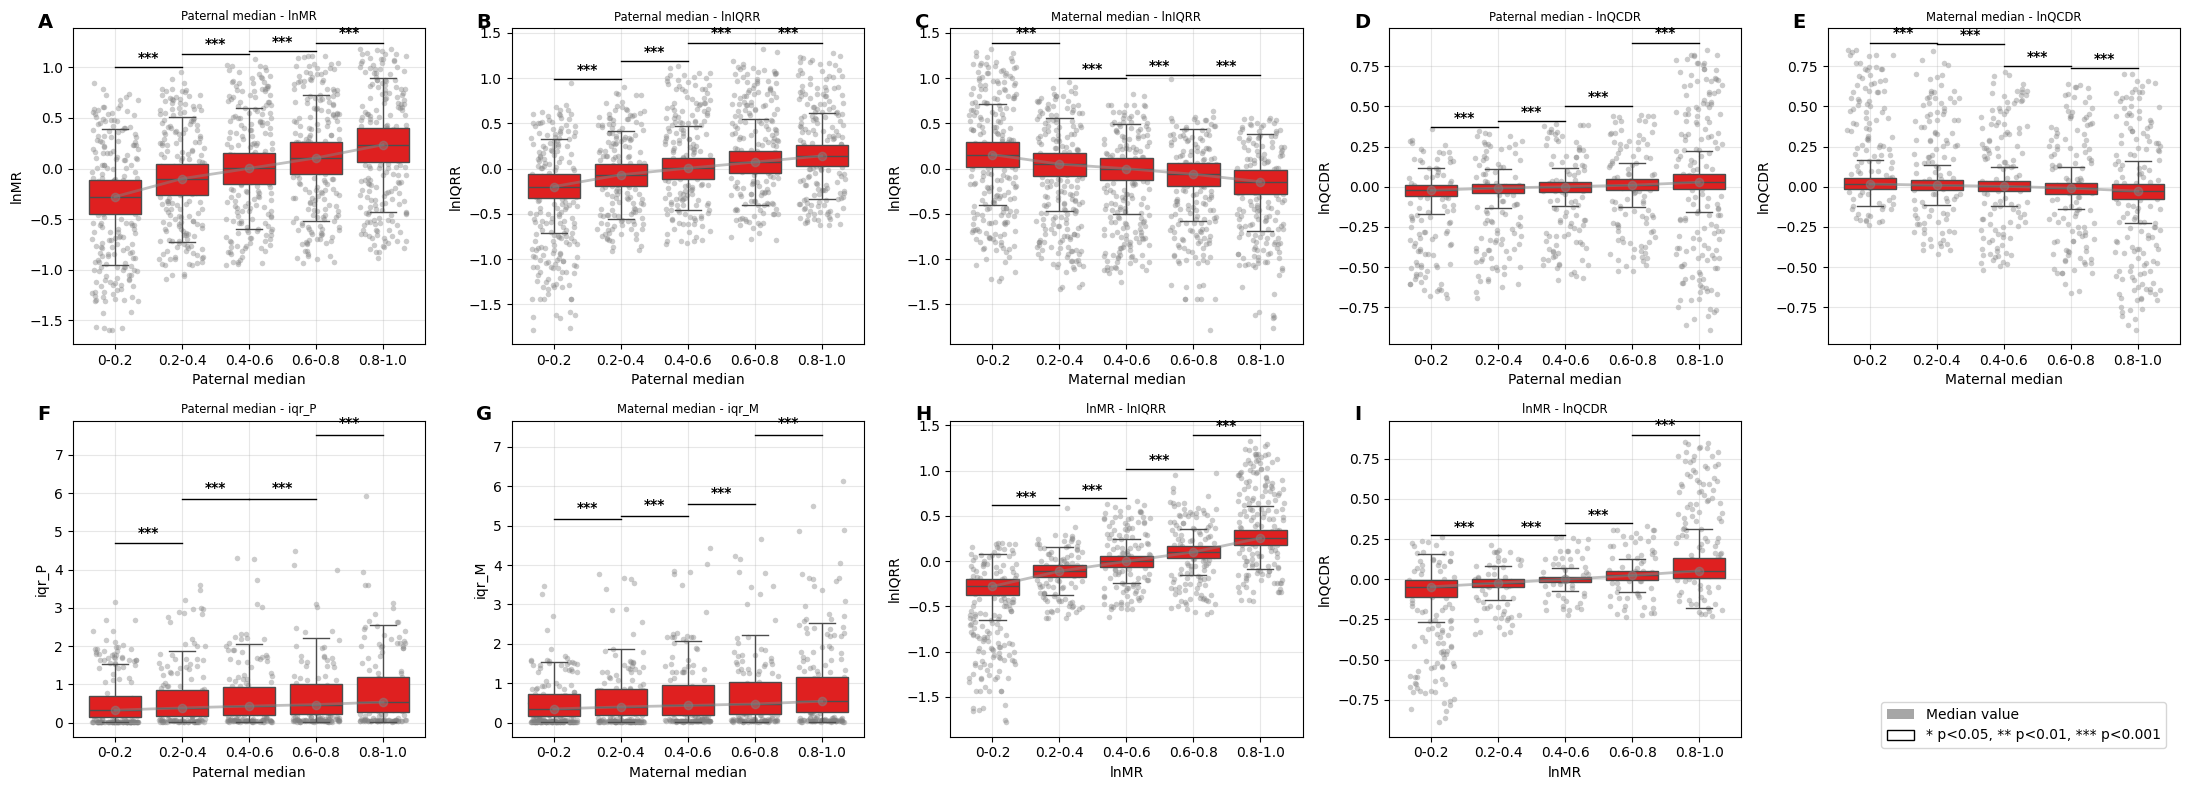

In [38]:
# ———— 绘图：2行5列 ————
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharey=False)

# ===== 第1行 =====
draw_panel(axes[0,0],
           data_box=yj_desc_data_wide, data_strip=yj_desc_data_wide_sampled_e,
           x_col='x_group_P', y_col=y_label_4e,
           x_label=x_label_left, y_label=y_label_4e, order=order, label='A')

draw_panel(axes[0,1],
           data_box=yj_desc_data_wide, data_strip=yj_desc_data_wide_sampled_left,
           x_col='x_group_P', y_col=y_label_4a,
           x_label=x_label_left, y_label=y_label_4a, order=order, label='B')

draw_panel(axes[0,2],
           data_box=yj_desc_data_wide, data_strip=yj_desc_data_wide_sampled_right,
           x_col='x_group_M', y_col=y_label_4a,
           x_label=x_label_right, y_label=y_label_4a, order=order, label='C')

draw_panel(axes[0,3],
           data_box=yj_desc_data_wide, data_strip=yj_desc_data_wide_sampled_f_P,
           x_col='x_group_P', y_col=y_label_4f,
           x_label=x_label_left, y_label=y_label_4f, order=order, label='D')

draw_panel(axes[0,4],
           data_box=yj_desc_data_wide, data_strip=yj_desc_data_wide_sampled_f_M,
           x_col='x_group_M', y_col=y_label_4f,
           x_label=x_label_right, y_label=y_label_4f, order=order, label='E')

# ===== 第2行 =====
draw_panel(axes[1,0],
           data_box=yj_desc_data_wide, data_strip=yj_desc_data_wide_sampled_left,
           x_col='x_group_P', y_col=y_label_4c,
           x_label=x_label_left, y_label=y_label_4c, order=order, label='F')

draw_panel(axes[1,1],
           data_box=yj_desc_data_wide, data_strip=yj_desc_data_wide_sampled_right,
           x_col='x_group_M', y_col=y_label_4d,
           x_label=x_label_right, y_label=y_label_4d, order=order, label='G')

# H图：lnMR分组 - lnIQRR
draw_panel(axes[1,2],
           data_box=yj_desc_data_wide, data_strip=yj_desc_data_wide_sampled_h,
           x_col='x_group_lnMR', y_col=y_label_4a,
           x_label='lnMR', y_label=y_label_4a, order=order, label='H')

# I图：lnMR分组 - lnQCDR
draw_panel(axes[1,3],
           data_box=yj_desc_data_wide, data_strip=yj_desc_data_wide_sampled_i,
           x_col='x_group_lnMR', y_col=y_label_4f,
           x_label='lnMR', y_label=y_label_4f, order=order, label='I')

axes[1,4].set_visible(False)   # 空白

# ———— 图例 & 保存 ————
legend_elements = [
    mpatches.Patch(facecolor='grey', alpha=0.7, label='Median value'),
    mpatches.Patch(facecolor='none', edgecolor='black',
                   label='* p<0.05, ** p<0.01, *** p<0.001')
]
fig.legend(handles=legend_elements, loc='lower right',
           bbox_to_anchor=(0.99, 0.05))

plt.tight_layout()
plot_path_1 = rf"D:\02.File\2025-2026学年第2学期\02.文章\2025.3.28\01.代码直出\2026.4.1.f_median_IQR.pdf"
plt.savefig(plot_path_1, format='pdf', dpi=300, bbox_inches='tight')
plt.show()

### 5、 lnMR与lnIQRR\lnMR与lnQCDR

In [6]:
# ———— 参数调整区 ————
BIN_SIZE = 0.05        # Y值分箱大小（根据lnIQRR范围调整）
SAMPLE_PER_BIN = 5     # 每箱保留的点数
y_label_5a = 'lnIQRR'
x_label_5a = 'lnMR'
y_label_5b = 'lnQCDR'
x_label_left = f'Paternal {x_label_5a}'
x_label_right = f'Maternal {x_label_5a}'
order = ['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0']
# ————————————————————
# 对散点图数据进行采样
sampled_indices_lnMR = bin_sampling_by_group(
    yj_desc_data_wide, 
    x_col='x_group_P',  # X轴分类变量
    y_col=x_label_5a,      # Y轴连续变量（用于分箱）
    bin_size=BIN_SIZE, 
    sample_per_bin=SAMPLE_PER_BIN
)
yj_desc_data_wide_sampled_lnMR = yj_desc_data_wide.loc[sampled_indices_lnMR].copy()

print(f"原始点数_left: {len(yj_desc_data_wide):,}")
print(f"median_P 采样后点数_left: {len(yj_desc_data_wide_sampled_lnMR):,}")
print(f"median_P 保留比例_left: {len(yj_desc_data_wide_sampled_lnMR)/len(yj_desc_data_wide)*100:.2f}%")

原始点数_left: 269,654
median_P 采样后点数_left: 966
median_P 保留比例_left: 0.36%


#### 5.2 绘图

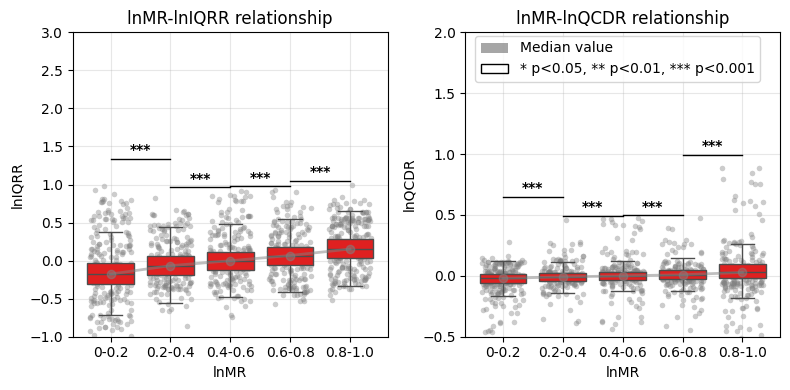

In [7]:
# ———— 绘图 ————
fig, axes = plt.subplots(1,2,figsize=(8,4))

# ================================================== A图：lnMR vs lnIQRR ==================================================
sns.boxplot(data=yj_desc_data_wide, x='x_group_P', y=y_label_5a, legend=False,order=order,showfliers=False,zorder=10,width=0.78,color='red',ax=axes[0])
sns.stripplot(data=yj_desc_data_wide_sampled_lnMR, x='x_group_P', y=y_label_5a, color='grey', alpha=0.4, jitter=0.35, size=4,zorder=0,ax=axes[0])
# 计算每个组的中位数并添加趋势线
medians_a = yj_desc_data_wide.groupby('x_group_P', observed=False)[y_label_5a].median().reindex(order)
x_positions_a = range(len(medians_a))
axes[0].plot(x_positions_a, medians_a.values, linestyle='-', linewidth=2, marker='o', markersize=6,label='Median trend', zorder=20, color='grey', alpha=0.5)
axes[0].set_xlabel(f'{x_label_5a}')
axes[0].set_ylabel(f'{y_label_5a}')
axes[0].set_title(f'{x_label_5a}-{y_label_5a} relationship')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-1,3)

# ================================================== A图显著性 ==================================================
# 计算显著性（C图和D图）
groups_a = [yj_desc_data_wide[yj_desc_data_wide['x_group_P'] == group][y_label_5a].dropna() for group in order]

for i in range(len(order)-1):
    # C图显著性
    stat_a, p_val_a = mannwhitneyu(groups_a[i], groups_a[i+1], alternative='two-sided')
    if p_val_c < 0.001:
        sig_symbol_c = '***'
    elif p_val_c < 0.01:
        sig_symbol_c = '**'
    elif p_val_c < 0.05:
        sig_symbol_c = '*'
    else:
        sig_symbol_c = 'ns'
    
    y_max_c = max(groups_a[i].max(), groups_a[i+1].max())
    y_pos_c = y_max_c + (y_max_c * 0.05)
    axes[0].plot([i, i+1], [y_pos_c, y_pos_c], 'k-', linewidth=1)
    axes[0].text((i + i+1)/2, y_pos_c + y_max_c*0.02, sig_symbol_c, 
                   ha='center', va='bottom', fontsize=10, fontweight='bold')

# ================================================== B图：lnMR vs lnQCDR ==================================================
sns.boxplot(data=yj_desc_data_wide, x='x_group_P', y=y_label_5b, legend=False,order=order,showfliers=False,zorder=10,width=0.78,color='red',ax=axes[1])
sns.stripplot(data=yj_desc_data_wide_sampled_lnMR, x='x_group_P', y=y_label_5b, color='grey', alpha=0.4, jitter=0.35, size=4,zorder=0,ax=axes[1])
# 计算每个组的中位数并添加趋势线
medians_a = yj_desc_data_wide.groupby('x_group_P', observed=False)[y_label_5b].median().reindex(order)
x_positions_a = range(len(medians_a))
axes[1].plot(x_positions_a, medians_a.values, linestyle='-', linewidth=2, marker='o', markersize=6,label='Median trend', zorder=20, color='grey', alpha=0.5)
axes[1].set_xlabel(f'{x_label_5a}')
axes[1].set_ylabel(f'{y_label_5b}')
axes[1].set_title(f'{x_label_5a}-{y_label_5b} relationship')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-0.5,2)

# ================================================== B图显著性 ==================================================
# 计算显著性（C图和D图）
groups_b = [yj_desc_data_wide[yj_desc_data_wide['x_group_P'] == group][y_label_5b].dropna() for group in order]

for i in range(len(order)-1):
    # C图显著性
    stat_a, p_val_a = mannwhitneyu(groups_b[i], groups_b[i+1], alternative='two-sided')
    if p_val_c < 0.001:
        sig_symbol_c = '***'
    elif p_val_c < 0.01:
        sig_symbol_c = '**'
    elif p_val_c < 0.05:
        sig_symbol_c = '*'
    else:
        sig_symbol_c = 'ns'
    
    y_max_c = max(groups_b[i].max(), groups_b[i+1].max())
    y_pos_c = y_max_c + (y_max_c * 0.05)
    axes[1].plot([i, i+1], [y_pos_c, y_pos_c], 'k-', linewidth=1)
    axes[1].text((i + i+1)/2, y_pos_c + y_max_c*0.02, sig_symbol_c, 
                   ha='center', va='bottom', fontsize=10, fontweight='bold')
    
# 添加图例说明
legend_elements = [mpatches.Patch(facecolor='grey', alpha=0.7, label='Median value'),
                   mpatches.Patch(facecolor='none', edgecolor='black', label='* p<0.05, ** p<0.01, *** p<0.001')]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.965, 0.915))
# fig.suptitle(f'Boxplot with Scatter Points: {y_label_left} by mean Groups', fontsize=14, y=1.02)
plt.tight_layout()
plot_path_2 = rf"D:\02.File\2025-2026学年第2学期\02.文章\2025.3.28\图\2026.3.28.c_lnMR_lnIQRR_lnQCDR.pdf"
plt.savefig(plot_path_2, format='pdf', dpi=300, bbox_inches='tight')
plt.show()